# AI-Powered Airbnb Listing Segmentation for Business Intelligence

## Introduction

### Why is preprocessing necessary?

Exploratory Data Analysis (EDA) provided a comprehensive understanding of the Airbnb dataset by examining feature distributions, relationships between variables, data quality, and potential anomalies. However, while EDA helps us understand the data, it does not prepare the dataset for machine learning.

Most clustering algorithms, particularly **K-Means**, rely on numerical distance calculations to group similar observations. If the dataset contains identifiers, textual information, variables measured on different scales, or redundant features, the resulting clusters may not accurately represent meaningful business segments.

The objective of preprocessing is to transform the cleaned Airbnb dataset into a **machine-learning-ready dataset** while preserving the information that contributes to meaningful business insights. Every preprocessing decision made throughout this notebook is based on statistical reasoning, machine learning best practices, and business relevance rather than arbitrary assumptions.

---

# Objectives

The preprocessing stage aims to achieve the following objectives:

- Remove features that do not contribute to listing segmentation.
- Transform categorical variables into numerical representations suitable for machine learning.
- Scale numerical variables to ensure equal contribution during distance calculations.
- Engineer meaningful features where appropriate.
- Produce a clean feature matrix that can be directly used for clustering algorithms.

---

# Preprocessing Workflow

```text
Load Clean Dataset
        │
        ▼
Understand Feature Types
        │
        ▼
Feature Selection
        │
        ▼
Feature Engineering
        │
        ▼
Categorical Encoding
        │
        ▼
Feature Scaling
        │
        ▼
Export Machine Learning Dataset
```

---

# Feature Selection Philosophy

One of the most critical decisions during preprocessing is determining **which features should participate in the clustering process**.

Not every column in a dataset contributes useful information for discovering meaningful customer or listing segments. Some variables merely identify records, while others may introduce unnecessary noise into the clustering algorithm.

For every feature, the following questions are considered before deciding whether to retain or remove it:

1. Does this feature differentiate one listing from another?
2. Would a business use this feature to make strategic decisions?
3. Can this feature improve the quality of customer segmentation?
4. Does the feature introduce redundancy or unnecessary noise?
5. Can the feature be transformed into a more informative representation?

Rather than removing columns arbitrarily, every decision will be documented and justified.

---

# Feature Decision Matrix

The following table will be populated during preprocessing after inspecting the dataset.

| Feature | Keep | Transformation | Business Justification |
|----------|------|----------------|------------------------|
| id | ❌ | Drop | Unique identifier with no analytical value |
| host id | ❌ | Drop | Unique identifier that does not describe listing characteristics |
| host name | ❌ | Drop | High-cardinality text unsuitable for clustering |
| ... | ... | ... | ... |

---

# Machine Learning Considerations

This project focuses on **unsupervised learning**, meaning there is **no target variable**. The clustering algorithm identifies hidden structures within the dataset based solely on similarities between listings.

Since K-Means relies on Euclidean distance, proper preprocessing is essential:

- Numerical variables should be on comparable scales.
- Categorical variables must be converted into numerical representations.
- Irrelevant identifiers should be removed.
- Features that distort distance calculations should be carefully handled.

The quality of preprocessing directly influences the quality, stability, and interpretability of the resulting clusters.

---

# Business Perspective

The objective of this project extends beyond assigning listings to arbitrary clusters.

The primary goal is to identify **business-relevant listing segments** that can support strategic decision-making.

Potential business applications include:

- Identifying premium and budget property segments.
- Understanding characteristics of highly reviewed listings.
- Supporting pricing strategies through segment-specific analysis.
- Enabling targeted marketing campaigns.
- Helping hosts optimize listing performance.
- Assisting platforms in recommending pricing and promotional strategies.

Every preprocessing step is therefore evaluated from both a **machine learning perspective** and a **business intelligence perspective**, ensuring that the resulting clusters are technically sound and practically useful.

---

> **Notebook Structure**

Throughout this notebook, major preprocessing decisions will be accompanied by two complementary viewpoints.

### Machine Learning Perspective

This section explains **why a preprocessing step is necessary from an algorithmic standpoint**.

Example topics include:

- Distance-based learning
- Feature scaling
- Encoding categorical variables
- Reducing noise
- Improving cluster quality

---

###  Business Perspective

This section explains **why the preprocessing step matters from a business standpoint**.

Example topics include:

- Improving interpretability
- Supporting pricing decisions
- Enhancing customer segmentation
- Enabling targeted marketing
- Producing actionable business insights

This dual-perspective approach ensures that every preprocessing decision is technically justified while remaining aligned with real-world business objectives.

In [6]:
#For data manipulation
import pandas as pd
import numpy as np
#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Saving preprocessed data
import joblib

#Displaying settings 
pd.set_option("display.max_columns", None)

#Ignore warnings 
import warnings 
warnings.filterwarnings("ignore")


In [7]:
#Loading the cleaned dataset
df = pd.read_excel(r"../data/raw/Airbnb_basic_cleaned.xls")
df.head()

,id,host id,host_identity_verified,host name,neighbourhood group,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules
0,1001254,80014485718,unconfirmed,Madaline,Brooklyn,40.64749,-73.97237,United States,US,False,strict,Private room,2020,966,193,10,9.0,2021-10-19,0.21,4,6,286,Clean up and treat the home the way you'd like...
1,1002102,52335172823,verified,Jenna,Manhattan,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007,142,28,30,45.0,2022-05-21,0.38,4,2,228,Pet friendly but please confirm with me if the...
2,1002403,78829239556,unconfirmed,Elise,Manhattan,40.80902,-73.94190,United States,US,True,flexible,Private room,2005,620,124,3,0.0,2019-06-23,0.74,5,1,352,"I encourage you to use my kitchen, cooking and..."
3,1002755,85098326012,unconfirmed,Garry,Brooklyn,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005,368,74,30,270.0,2019-07-05,4.64,4,1,322,Not provided
4,1003689,92037596077,verified,Lyndon,Manhattan,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009,204,41,10,9.0,2018-11-19,0.10,3,1,289,"Please no smoking in the house, porch or on th..."


### Initial Dataset inspection 
This inspection will help verify the following:
- Dataset dimensions 
- Feature names
- Data types 
- Missing values 
- General Structure.

In [8]:
print(f"Dataset Shape : {df.shape}")

print("\n")

df.info()

Dataset Shape : (65535, 23)


<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              65535 non-null  int64         
 1   host id                         65535 non-null  int64         
 2   host_identity_verified          65535 non-null  str           
 3   host name                       65535 non-null  object        
 4   neighbourhood group             65535 non-null  str           
 5   lat                             65527 non-null  float64       
 6   long                            65527 non-null  float64       
 7   country                         65535 non-null  str           
 8   country code                    65535 non-null  str           
 9   instant_bookable                65535 non-null  bool          
 10  cancellation_policy             65478 non-null  str

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,65535.0,NaN,NaN,NaN,19098550.149996,1001254.0,10049943.0,19098550.0,28147157.0,37195764.0,10448670.584823
host id,65535.0,NaN,NaN,NaN,49343621381.189758,130349612.0,24664062957.0,49206220974.0,74131945893.0,98763129024.0,28537359003.777672
host_identity_verified,65535,2,unconfirmed,32897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host name,65535,12964,Michael,545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood group,65535,7,Manhattan,28099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,65527.0,NaN,NaN,NaN,40.728097,40.49979,40.68862,40.72261,40.76279,40.91697,0.055913
long,65527.0,NaN,NaN,NaN,-73.949317,-74.24984,-73.98292,-73.95456,-73.931805,-73.70522,0.050248
country,65535,2,United States,65212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country code,65535,1,US,65535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instant_bookable,65535,2,False,33036,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Feature Decision Matrix

Before transforming the dataset, each feature is evaluated based on both its machine learning relevance and its business value.

The objective of this exercise is to determine whether a feature should be retained, transformed, engineered into a new feature, or removed entirely from the clustering dataset.

Each decision is justified from two perspectives:

- **Machine Learning Perspective:** Does the feature improve the clustering process?
- **Business Perspective:** Can the feature contribute to meaningful business insights and decision-making?

This systematic approach improves transparency, reproducibility, and interpretability throughout the preprocessing pipeline.

| Feature | Keep | Transformation | Machine Learning Justification | Business Justification |
|----------|:----:|----------------|--------------------------------|------------------------|
| id | No | Drop | Unique identifier that carries no predictive information and adds unnecessary dimensionality. | Used only for record identification and provides no business insight for segmentation. |
| host id | No | Drop | Unique identifier that does not describe listing characteristics. | Useful for database management but not for business analysis. |
| host_identity_verified | Yes | Binary Encoding | Low-cardinality categorical feature suitable for machine learning models. | Indicates host credibility, which may influence customer booking behaviour. |
| host name | No | Drop | High-cardinality text feature that introduces noise without improving clustering. | Individual host names do not provide strategic business insights. |
| neighbourhood group | Yes | One-Hot Encoding | Important categorical feature representing geographical location. | Enables identification of location-based market segments and pricing patterns. |
| lat | Yes | Standardization | Numerical geographic feature useful for identifying spatial relationships. | Geographic location strongly influences customer demand and pricing. |
| long | Yes | Standardization | Numerical geographic feature that complements latitude. | Helps identify regional trends and neighbourhood clusters. |
| country | No | Drop | Nearly constant feature providing little or no variance. | Does not contribute meaningful information if all listings belong to the same country. |
| country code | No | Drop | Duplicate representation of the country feature. | Redundant information with no additional business value. |
| instant_bookable | Yes | Binary Encoding | Binary feature representing booking behaviour. | Indicates customer convenience and host flexibility. |
| cancellation_policy | Yes | One-Hot Encoding | Low-cardinality categorical feature appropriate for encoding. | Reflects host risk management and booking flexibility. |
| room type | Yes | One-Hot Encoding | One of the most influential categorical variables for clustering. | Differentiates listings based on accommodation type. |
| Construction year | Yes | Feature Engineering (Property Age) | Property age is more informative than construction year for measuring listing characteristics. | Property age is easier to interpret and more relevant for business decisions. |
| price | Yes | Standardization | Continuous feature requiring scaling for distance-based algorithms. | Represents the primary pricing metric used for market segmentation. |
| service fee | Yes | Standardization | Continuous numerical feature requiring scaling. | Contributes to pricing strategy and revenue analysis. |
| minimum nights | Yes | Standardization | Continuous booking constraint requiring scaling. | Reflects booking policies and target customer segments. |
| number of reviews | Yes | Standardization | Measures listing popularity and customer engagement. | Helps identify highly demanded listings. |
| last review | Yes | Feature Engineering (Days Since Last Review) | Recency provides more useful information than an absolute date. | Indicates how active and recently engaged a listing is. |
| reviews per month | Yes | Standardization | Continuous engagement metric requiring scaling. | Represents booking frequency and listing demand. |
| review rate number | Yes | Standardization | Continuous quality metric requiring scaling. | Indicates customer satisfaction and perceived listing quality. |
| calculated host listings count | Yes | Standardization | Measures host activity and experience. | Distinguishes professional hosts from occasional hosts. |
| availability 365 | Yes | Standardization | Continuous availability feature requiring scaling. | Helps infer occupancy levels and booking demand. |
| house_rules | Future Enhancement | NLP Feature Extraction | Excluded from the baseline clustering model but retained for future NLP-based feature extraction. | House rules may reveal hidden behavioural and property characteristics, enabling richer AI-powered segmentation in future work. |

# Feature Engineering :
For this project, two new features are created:

- **Property Age**, derived from the construction year of the listing.
- **Days Since Last Review**, derived from the date of the most recent review.

These engineered features provide more intuitive measures of property characteristics and listing activity than the original variables.

After creating these features, the original columns will be removed to avoid redundancy in the clustering dataset.

## Engineering Feature 1: Property Age

### Rationale

The original dataset contains the **Construction year** of each Airbnb listing. While this value is informative, the raw construction year itself provides limited meaning during clustering.

For example, the values **2008** and **2012** indicate construction years but do not directly communicate how old the properties are. From both a machine learning and business perspective, the **age of a property** is generally a more meaningful attribute than its construction year.

Older properties may differ from newer ones in terms of pricing, customer perception, maintenance requirements, and booking behaviour.

Therefore, the **Construction year** feature is transformed into **Property Age**, which represents the number of years since the property was constructed.

After creating the new feature, the original **Construction year** column is removed to eliminate redundancy.

### Machine Learning Perspective

Using **Property Age** produces a continuous numerical feature that is easier for clustering algorithms to interpret than absolute calendar years.

### Business Perspective

Businesses often evaluate properties based on their age rather than the year they were built. Property age is more intuitive when analysing maintenance, renovation requirements, pricing strategies, and customer preferences.

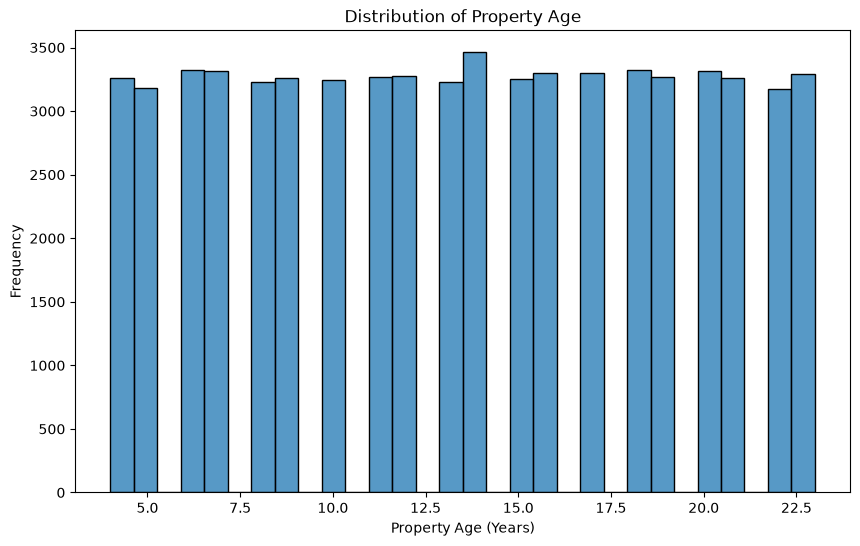

In [11]:
#create property age
current_year = pd.Timestamp.today().year

df["Property Age"] = current_year - df["Construction year"]

#Removing the original column

df.drop(columns=["Construction year"],inplace=True)

#validating the change with a histogram

plt.figure(figsize=(10,6))
sns.histplot(df["Property Age"], bins=30)
plt.title("Distribution of Property Age")
plt.xlabel("Property Age (Years)")
plt.ylabel("Frequency")
plt.show()

## Engineering Feature 2: Days Since Last Review

### Rationale

The dataset records the **date of the most recent review** for each listing.

Although timestamps contain useful information, machine learning algorithms cannot directly interpret calendar dates. More importantly, the absolute review date is less informative than **how recently a listing has been reviewed**.

To capture listing activity, the **Last Review** column is transformed into **Days Since Last Review**, representing the number of days between the most recent review and the current date.

Listings reviewed recently are generally more active and may indicate higher customer engagement, whereas listings with older reviews may represent lower activity or declining popularity.

After creating the new feature, the original **Last Review** column is removed to prevent redundant information from entering the clustering model.

### Machine Learning Perspective

Transforming timestamps into numerical recency values creates a feature that can be directly used by clustering algorithms.

### Business Perspective

Listing recency serves as an indicator of customer activity and market relevance. Businesses can use this information to identify active, declining, or inactive property segments.

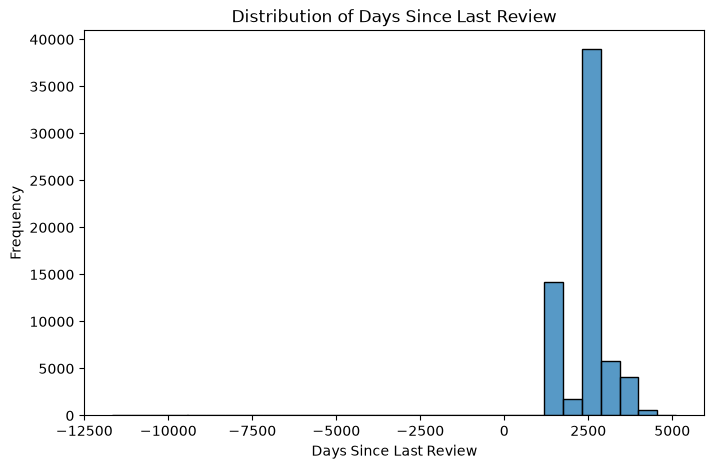

In [13]:
#calculating the days since last review of a listing
today = pd.Timestamp.today()

df["Days Since Last Review"] = (today - df["last review"]).dt.days

#Removing the original column
df.drop(columns=["last review"],inplace=True)

#Validating the change with a histogram

plt.figure(figsize=(8,5))
sns.histplot(df["Days Since Last Review"], bins=30)
plt.title("Distribution of Days Since Last Review")
plt.xlabel("Days Since Last Review")
plt.ylabel("Frequency")
plt.show()

## Evaluation of the Engineered Feature: Days Since Last Review

The feature **Days Since Last Review** was engineered by converting the original `last review` timestamp into a numerical measure of review recency. Under normal circumstances, this transformation provides a meaningful indicator of listing activity, customer engagement, and market relevance, making it a valuable feature for clustering and business analysis.

However, upon evaluating the engineered feature, it was observed that the majority of listings exhibit values of approximately **2,500 days since the last review**. This is expected because the Airbnb dataset used in this project is a **historical snapshot**, with the most recent reviews dating back several years.

From a machine learning perspective, the feature remains mathematically valid. However, from a business perspective, its practical value is limited. Since all listings are affected by the same historical time gap, the feature primarily reflects the age of the dataset rather than the current activity or popularity of individual listings. Consequently, it contributes little meaningful variation for customer or listing segmentation.

For this reason, **Days Since Last Review** will not be included in the final clustering model. This decision ensures that the segmentation is driven by features that represent genuine differences between listings rather than artifacts introduced by the historical nature of the dataset.

The feature engineering process has nevertheless been documented to demonstrate the transformation of temporal data into numerical features, which remains a valuable preprocessing technique for real-time or continuously updated datasets.